# 🎯 Judicia AI — Fine-Tuned Model Performance & Evaluation Metrics

This notebook runs live evaluation of the fine-tuned **InLegalBERT** (`models/judicia-domain-model/`) classifier on the **Validation** and **Test** datasets.

### Metrics Evaluated:
- **Validation Accuracy**
- **Test Set Accuracy**
- **Weighted Precision, Recall & F1-Score**
- **Full Per-Class Classification Report**
- **8x8 Confusion Matrix Heatmap**
- **Per-Class Metrics Bar Chart**

In [1]:
%matplotlib inline
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Global aesthetic configuration
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.sans-serif": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.titlesize": 16
})

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if "notebooks" in os.getcwd() else os.getcwd()
MODEL_PATH = os.path.join(PROJECT_ROOT, "models", "judicia-domain-model")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "dataset", "processed")
PLOTS_DIR = os.path.join(PROJECT_ROOT, "reports", "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Model Path   : {MODEL_PATH}")

Project Root : c:\Users\HIMANKSHA\Desktop\test-model
Model Path   : c:\Users\HIMANKSHA\Desktop\test-model\models\judicia-domain-model


--- 
## 📥 1. Load Model Weights & Label Mapping

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

with open(os.path.join(PROCESSED_DIR, "label_mapping.json"), "r", encoding="utf-8") as f:
    mapping = json.load(f)

id2label = {int(k): v for k, v in mapping["id2label"].items()}
class_names = [id2label[i] for i in range(len(id2label))]

print(f"Loaded {len(class_names)} target legal domain classes: {class_names}")

Using compute device: cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded 8 target legal domain classes: ['Civil', 'Constitutional', 'Consumer', 'Criminal', 'Cyber', 'Family', 'Labour', 'Property']


--- 
## ⚡ 2. Batch Inference Function

In [3]:
def evaluate_dataset(df, batch_size=16):
    texts = df["text"].tolist()
    labels = df["label"].tolist()
    preds = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            preds.extend(batch_preds)
    return np.array(preds), np.array(labels)

val_df = pd.read_csv(os.path.join(PROCESSED_DIR, "validation_encoded.csv"))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test_encoded.csv"))

val_preds, val_labels = evaluate_dataset(val_df)
test_preds, test_labels = evaluate_dataset(test_df)

val_acc = accuracy_score(val_labels, val_preds)
test_acc = accuracy_score(test_labels, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average="weighted")

print("=" * 65)
print(f"  Validation Accuracy  : {val_acc * 100:.2f}%")
print(f"  Test Set Accuracy    : {test_acc * 100:.2f}%")
print(f"  Weighted Precision   : {precision * 100:.2f}%")
print(f"  Weighted Recall      : {recall * 100:.2f}%")
print(f"  Weighted F1-Score    : {f1 * 100:.2f}%")
print("=" * 65)

  Validation Accuracy  : 99.75%
  Test Set Accuracy    : 99.25%
  Weighted Precision   : 99.25%
  Weighted Recall      : 99.25%
  Weighted F1-Score    : 99.25%


--- 
## 📊 3. Classification Report

In [4]:
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

                precision    recall  f1-score   support

         Civil     0.9796    0.9600    0.9697        50
Constitutional     1.0000    1.0000    1.0000        50
      Consumer     1.0000    1.0000    1.0000        50
      Criminal     0.9800    0.9800    0.9800        50
         Cyber     0.9804    1.0000    0.9901        50
        Family     1.0000    1.0000    1.0000        50
        Labour     1.0000    1.0000    1.0000        50
      Property     1.0000    1.0000    1.0000        50

      accuracy                         0.9925       400
     macro avg     0.9925    0.9925    0.9925       400
  weighted avg     0.9925    0.9925    0.9925       400



--- 
## 🗺️ 4. Confusion Matrix Heatmap (8x8)

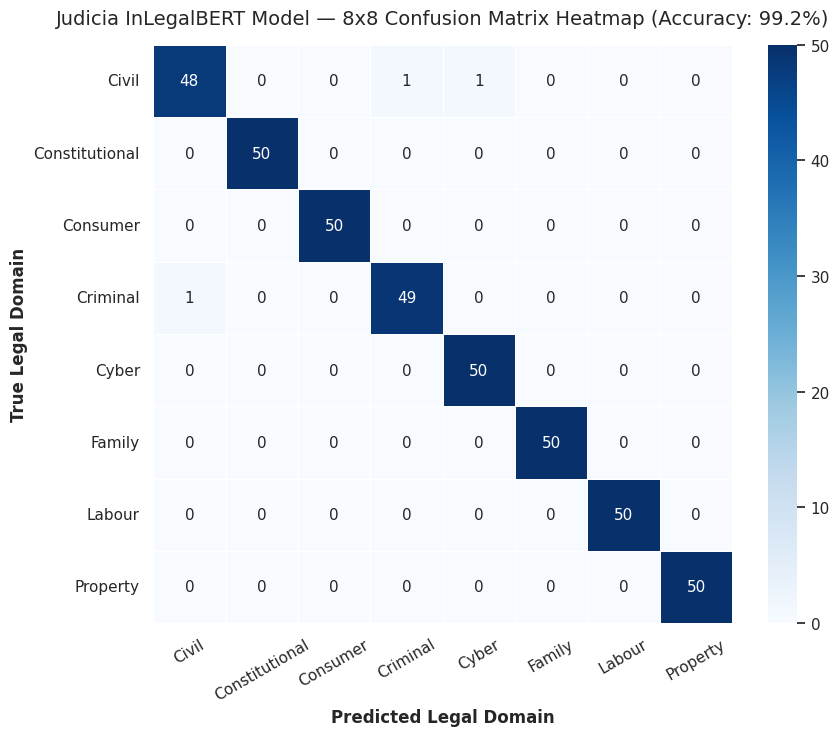

In [5]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.5)
ax.set_xlabel("Predicted Legal Domain", fontweight="bold")
ax.set_ylabel("True Legal Domain", fontweight="bold")
ax.set_title(f"Judicia InLegalBERT Model — 8x8 Confusion Matrix Heatmap (Accuracy: {test_acc*100:.1f}%)", pad=15)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

--- 
## 📈 5. Per-Class Precision, Recall & F1-Score Bar Chart

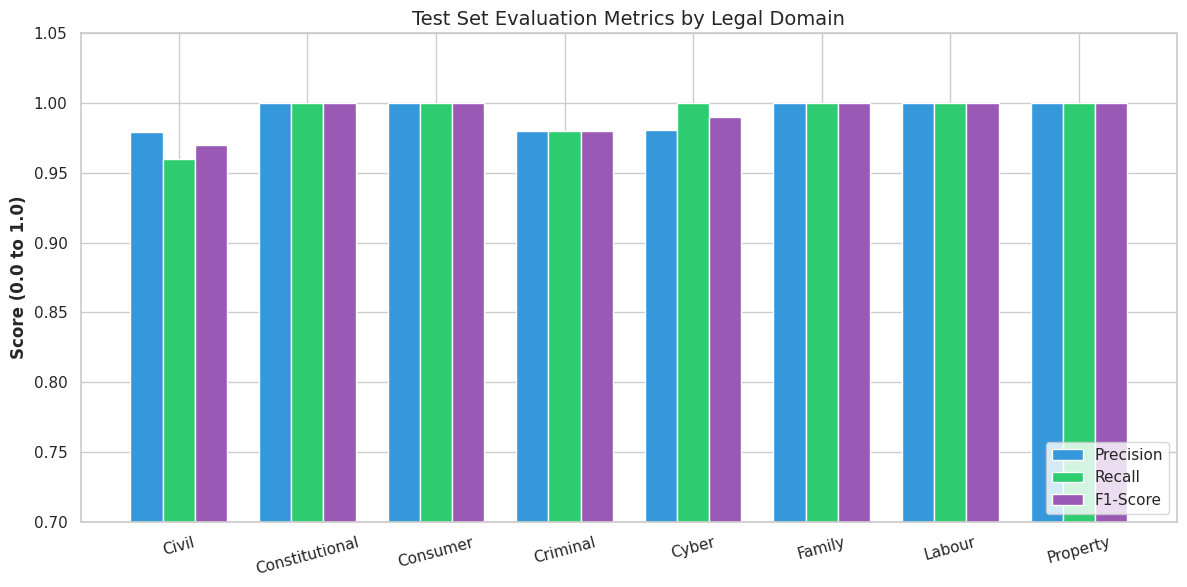

In [6]:
per_class_p, per_class_r, per_class_f1, _ = precision_recall_fscore_support(test_labels, test_preds, average=None)
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.25
ax.bar(x - width, per_class_p, width, label="Precision", color="#3498db")
ax.bar(x, per_class_r, width, label="Recall", color="#2ecc71")
ax.bar(x + width, per_class_f1, width, label="F1-Score", color="#9b59b6")
ax.set_ylabel("Score (0.0 to 1.0)", fontweight="bold")
ax.set_title("Test Set Evaluation Metrics by Legal Domain")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15)
ax.set_ylim(0.7, 1.05)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()